# Pulse shaping for the resonant trapping protocol — what works and what doesn't

This companion notebook investigates **pulse shaping** as a route to suppress the
counter-rotating (blue-sideband / anti-Jaynes–Cummings) leakage identified in
`Improved_pulse_sequence.ipynb`, and compares it against two reference points:

| approach | what is tuned | from |
|---|---|---|
| **(1) nominal resonant protocol** | nothing (square X-pulse, $\Omega=\nu$) | the draft / first approach |
| **(2) refocusing + detuning** | pulse length $f$ and a small detuning $\delta$ | `Improved_pulse_sequence.ipynb` |
| **(3) pulse shaping** | the X-pulse **envelope** $\Omega(t)$ | this notebook |

**The idea behind pulse shaping.** The leakage comes from the counter-rotating term, which
in the resonant frame rotates at $2\nu$. A square pulse has sharp edges and therefore a
broad, slowly-decaying ($\sim1/f$) spectrum with appreciable weight at $\pm2\nu$. Replacing
it with a smooth envelope (Hann, Blackman, flat-top with cosine ramps, …) of the **same
pulse area** — so the Jaynes–Cummings rotation angle is unchanged — should narrow the
spectrum and suppress the $2\nu$ component, hence the leakage. This is the intuition behind
the Gaussian attempt in the main simulation notebook.

We will see that **this intuition fails for the resonant ($\Omega=\nu$) protocol**, find out
exactly why, and conclude that the only viable "shaping" here lives in the
*(length, detuning)* space of approach (2).

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
plt.rcParams.update({'text.usetex': False, 'font.size': 12, 'figure.dpi': 110})

# ---------------- shared setup (full dissipative spin reset with photon recoil) ----------------
nu, n0, Omega, N, nbar, R = 1.0, 1, 1.0, 16, 1.0, 40

a = destroy(N); ad = a.dag()
sz = tensor(sigmaz(), qeye(N)); sx = tensor(sigmax(), qeye(N))
sp = tensor(sigmap(), qeye(N)); sm = tensor(sigmam(), qeye(N))
A  = tensor(qeye(2), a); Ad = tensor(qeye(2), ad); num = tensor(qeye(2), ad*a)
gket = basis(2, 1); projs = [fock_dm(N, n) for n in range(N)]

def thermal_p(N, nbar): p = (nbar/(nbar+1.0))**np.arange(N); return p/p.sum()
def ideal_trapped(p0, n0=1):
    N = len(p0); out = np.zeros(N); m = 0
    while n0*m**2 < N:
        lo, hi = n0*m**2, min(n0*(m+1)**2, N); out[lo] = p0[lo:hi].sum(); m += 1
    return out/out.sum()
def tdist(p, q): return 0.5*np.sum(np.abs(np.array(p)-np.array(q)))

p0  = thermal_p(N, nbar)
pid = ideal_trapped(p0, n0)

def window(name, M):
    t = np.linspace(0, 1, M)
    if name == "square": return np.ones(M)
    if name == "cos":    return 0.5*(1 - np.cos(2*np.pi*t))                       # Hann
    if name == "black":  return 0.42 - 0.5*np.cos(2*np.pi*t) + 0.08*np.cos(4*np.pi*t)  # Blackman
    if name == "flattop":
        w = np.ones(M); r = max(1, M//4)
        ramp = 0.5*(1 - np.cos(np.pi*np.arange(r)/r)); w[:r] = ramp; w[-r:] = ramp[::-1]; return w
    raise ValueError(name)

def Dop(eta): return tensor(qeye(2), displace(N, 1j*eta))


# --- dissipative spin reset with photon recoil (main-text model, gamma = 1000) ---
import os, tempfile
gamma_reset = 1000.0
_RESET_CACHE = {}

def reset_super(N_, eta):
    """Dense column-stacked superoperator of the dissipative reset
    (duration tg = 4/gamma) with photon recoil, as in the main notebook."""
    key = (N_, round(float(eta), 6))
    if key not in _RESET_CACHE:
        fname = os.path.join(tempfile.gettempdir(), f"reset_{N_}_{key[1]}.npy")
        if os.path.exists(fname):
            _RESET_CACHE[key] = np.load(fname)
        else:
            aa = destroy(N_); xop_ = aa + aa.dag()
            smf = tensor(sigmam(), qeye(N_))
            numf = tensor(qeye(2), aa.dag()*aa)
            cosmax = 100
            cosal = np.arange(-cosmax, cosmax + 1)/cosmax
            Wd = 3*(cosal**2 + 1)/4/(2*cosmax); Wd = Wd/np.sum(Wd)
            G = gamma_reset/2; tg = 2/G
            c_ops = [np.sqrt(G*Wd[i])*(smf*tensor(qeye(2), (1j*c*eta*xop_).expm()))
                     for i, c in enumerate(cosal)]
            c_ops.append(np.sqrt(gamma_reset)*smf)
            Ld = (liouvillian(1.0*numf, c_ops)*tg).expm().full()
            _RESET_CACHE[key] = np.ascontiguousarray(Ld)
            np.save(fname, _RESET_CACHE[key])
    return _RESET_CACHE[key]

def _evolve_diss(U, eta, p_init, R_, N_):
    Ud = U.full(); Ld = reset_super(N_, eta); dim = 2*N_
    rho = np.zeros((dim, dim), dtype=complex)
    rho[N_:, N_:] = np.diag(p_init)          # |g><g| x rho_m
    for _ in range(R_):
        rho = Ud @ rho @ Ud.conj().T
        rho = (Ld @ rho.flatten(order='F')).reshape((dim, dim), order='F')
    d = np.real(np.diag(rho))
    return d[:N_] + d[N_:]

def _iterate(U, eta, p_init=None, reset='dissipative'):
    #   reset='dissipative': full reset model with photon recoil (default)
    #   reset='ideal':       instantaneous perfect reset (coherent analysis only)
    if reset == 'dissipative':
        return _evolve_diss(U, eta, p0 if p_init is None else p_init, R, N)
    rho_m = Qobj(np.diag(p0 if p_init is None else p_init), dims=[[N], [N]])
    for _ in range(R):
        rho = tensor(gket*gket.dag(), rho_m); rho = U*rho*U.dag(); rho_m = rho.ptrace(1)
    return np.real(np.array(expect(projs, rho_m)))

# ---- (1)/(2): full sequence with a SQUARE X-pulse; supports refocus (f) + detuning (delta) ----
def prep_square(eta, tau_factor=1.0, delta_x=0.0, Omega_y=100.0, RF=1.0):
    D = Dop(eta); tau = tau_factor*2*np.pi/(eta*Omega*np.sqrt(n0))
    U_rf = (-1j*0.5*RF*(A+Ad)*(eta/RF)).expm(); U_rf_u = U_rf.dag()
    H_y = 0.5*Omega_y*(-1j*sp*D + 1j*sm*D.dag()); ty = np.pi/(2*Omega_y)
    U_y = (-1j*H_y*ty).expm(); U_y_u = (1j*H_y*ty).expm()
    H_x = 0.5*delta_x*sx + nu*num + 0.5*Omega*(sp*D + sm*D.dag())
    U_x = (-1j*H_x*tau).expm()
    return _iterate(U_rf_u*U_y_u*U_x*U_y*U_rf, eta)

# ---- (3): full sequence with an amplitude-SHAPED X-pulse (same area => same JC rotation) ----
def prep_shaped(eta, shape="cos", kappa=1.0, M=50, Omega_y=100.0, RF=1.0):
    D = Dop(eta); tau = 2*np.pi/(eta*Omega*np.sqrt(n0)); T = kappa*tau
    w = window(shape, M); dt = T/M
    Om_t = w*(Omega*tau)/(np.sum(w)*dt)          # normalise pulse area to Omega*tau
    U_x = tensor(qeye(2), qeye(N))
    for k in range(M):
        Hk = nu*num + 0.5*Om_t[k]*(sp*D + sm*D.dag())
        U_x = (-1j*Hk*dt).expm()*U_x
    U_rf = (-1j*0.5*RF*(A+Ad)*(eta/RF)).expm(); U_rf_u = U_rf.dag()
    H_y = 0.5*Omega_y*(-1j*sp*D + 1j*sm*D.dag()); ty = np.pi/(2*Omega_y)
    U_y = (-1j*H_y*ty).expm(); U_y_u = (1j*H_y*ty).expm()
    return _iterate(U_rf_u*U_y_u*U_x*U_y*U_rf, eta)

print("setup ready (N=%d, R=%d, nbar=%.1f)" % (N, R, nbar))

setup ready (N=16, R=40, nbar=1.0)


## 1. Benchmark: does amplitude shaping help?

We compare, across $\eta$, the trace distance to the ideal trap for:
the **nominal** square pulse, the **best smooth-window** pulse (Hann / Blackman / flat-top,
area-matched), and the **refocusing + detuning** preparation (a small scan over the
pulse-length factor $f$ and detuning $\delta$, as in the companion notebook).

  eta   nominal   best-shaped  refocus+delta   best window
  0.2    0.1485        0.3846         0.0358   cos(k=2)
  0.3    0.0434        0.3404         0.0240   cos(k=2)
  0.4    0.2176        0.1964         0.0542   flattop(k=1)
  0.5    0.4102        0.4756         0.0814   flattop(k=2)


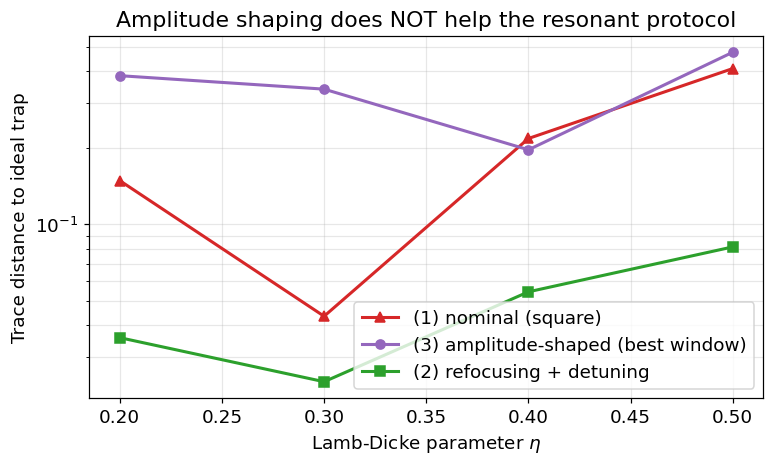

In [8]:
etas = [0.2, 0.3, 0.4, 0.5]
windows = ["cos", "black", "flattop"]

td_nom, td_shaped, td_fix = [], [], []
best_window = []
for eta in etas:
    td_nom.append(tdist(prep_square(eta), pid))
    # best amplitude window (area-matched, kappa=1) and also try a longer kappa=2
    cand = []
    for sh in windows:
        for kap in (1.0, 2.0):
            cand.append((tdist(prep_shaped(eta, sh, kap), pid), f"{sh}(k={kap:g})"))
    cand.sort(); td_shaped.append(cand[0][0]); best_window.append(cand[0][1])
    # refocusing + detuning: small scan
    best = (1e9, 1.0, 0.0)
    for f in np.linspace(0.90, 1.10, 11):
        for de in np.linspace(-0.3, 0.3, 9):
            d = tdist(prep_square(eta, tau_factor=f, delta_x=de), pid)
            if d < best[0]: best = (d, f, de)
    td_fix.append(best[0])

print(f"{'eta':>5} {'nominal':>9} {'best-shaped':>13} {'refocus+delta':>14}   best window")
for i, eta in enumerate(etas):
    print(f"{eta:>5} {td_nom[i]:>9.4f} {td_shaped[i]:>13.4f} {td_fix[i]:>14.4f}   {best_window[i]}")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(etas, td_nom,    '^-', color='tab:red',   lw=2, label='(1) nominal (square)')
ax.plot(etas, td_shaped, 'o-', color='tab:purple',lw=2, label='(3) amplitude-shaped (best window)')
ax.plot(etas, td_fix,    's-', color='tab:green', lw=2, label='(2) refocusing + detuning')
ax.set_xlabel(r'Lamb-Dicke parameter $\eta$'); ax.set_ylabel('Trace distance to ideal trap')
ax.set_yscale('log'); ax.grid(True, which='both', alpha=0.3); ax.legend()
ax.set_title('Amplitude shaping does NOT help the resonant protocol')
plt.tight_layout(); plt.show()

### 1a. The individual windows: Square, Hann, Blackman, flat-top

The benchmark above only reported the *best* window. Here we look at each smooth shape on
its own — **Hann** and **Blackman** (the two classic tapering windows) plus a cosine-ramped
**flat-top** — all area-matched to the square pulse so the Jaynes–Cummings rotation is
identical. The left panel shows the envelopes $\Omega(t)$; the right panel shows the
resulting trace distance versus $\eta$, with the refocusing + detuning curve for reference.

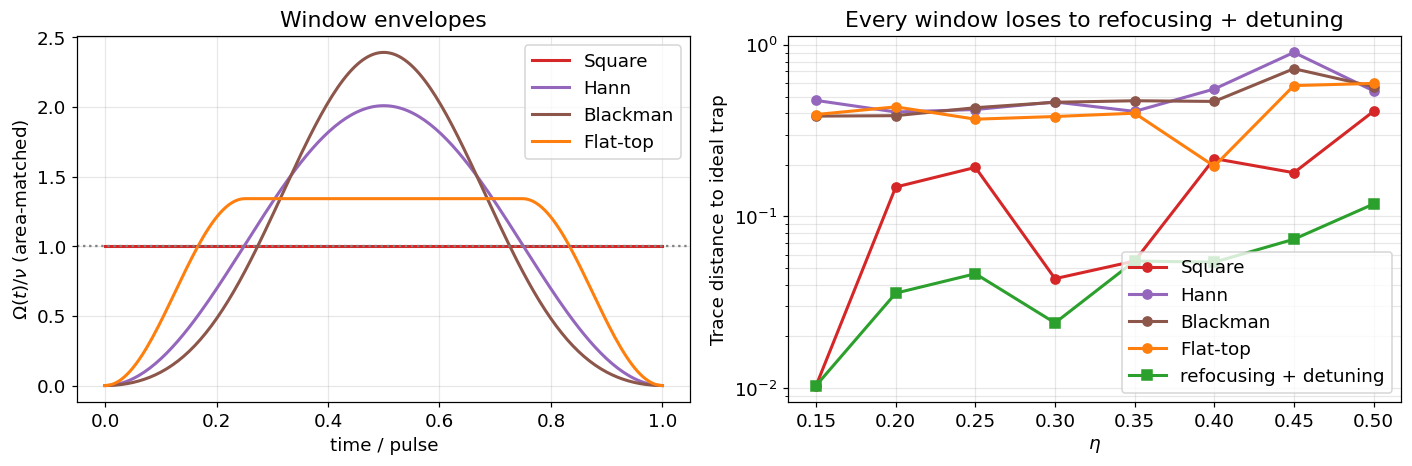

  eta    Square      Hann  Blackman  Flat-top  refoc+del
 0.15    0.0103    0.4749    0.3846    0.3930     0.0103
  0.2    0.1485    0.4066    0.3869    0.4354     0.0358
 0.25    0.1932    0.4201    0.4306    0.3691     0.0464
  0.3    0.0434    0.4651    0.4631    0.3826     0.0240
 0.35    0.0550    0.4097    0.4727    0.4000     0.0550
  0.4    0.2176    0.5532    0.4684    0.1964     0.0542
 0.45    0.1799    0.9041    0.7268    0.5793     0.0737
  0.5    0.4102    0.5399    0.5709    0.5966     0.1182


In [9]:
# Each window on its own (area-matched, kappa = 1), compared across eta
shape_map = {"Square": "square", "Hann": "cos", "Blackman": "black", "Flat-top": "flattop"}
shape_col = {"Square": "tab:red", "Hann": "tab:purple", "Blackman": "tab:brown", "Flat-top": "tab:orange"}
etas2 = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

td_shapes = {name: [tdist(prep_shaped(e, key, 1.0), pid) for e in etas2]
             for name, key in shape_map.items()}

# refocusing + detuning reference on the same eta grid (light scan)
td_ref = []
for e in etas2:
    best = 1e9
    for f in np.linspace(0.90, 1.10, 11):
        for de in np.linspace(-0.3, 0.3, 7):
            best = min(best, tdist(prep_square(e, tau_factor=f, delta_x=de), pid))
    td_ref.append(best)

fig, (aL, aR) = plt.subplots(1, 2, figsize=(13, 4.4))
Mv = 200; tt = np.linspace(0, 1, Mv)
for name, key in shape_map.items():
    w = window(key, Mv).astype(float)
    w = w*(np.sum(window("square", Mv))/np.sum(w))     # area-match to square
    aL.plot(tt, w, color=shape_col[name], lw=2, label=name)
aL.axhline(1.0, color='gray', ls=':')
aL.set_xlabel('time / pulse'); aL.set_ylabel(r'$\Omega(t)/\nu$ (area-matched)')
aL.set_title('Window envelopes'); aL.legend(); aL.grid(True, alpha=0.3)

for name in shape_map:
    aR.plot(etas2, td_shapes[name], 'o-', color=shape_col[name], lw=2, label=name)
aR.plot(etas2, td_ref, 's-', color='tab:green', lw=2, label='refocusing + detuning')
aR.set_xlabel(r'$\eta$'); aR.set_ylabel('Trace distance to ideal trap')
aR.set_yscale('log'); aR.grid(True, which='both', alpha=0.3); aR.legend()
aR.set_title('Every window loses to refocusing + detuning')
plt.tight_layout(); plt.show()

print(f"{'eta':>5} " + " ".join(f"{n:>9}" for n in shape_map) + f" {'refoc+del':>10}")
for i, e in enumerate(etas2):
    print(f"{e:>5} " + " ".join(f"{td_shapes[n][i]:>9.4f}" for n in shape_map) + f" {td_ref[i]:>10.4f}")

**Result.** Amplitude shaping is **never competitive** with refocusing + detuning, and is
*worse* than the plain square pulse across most of the range (the one exception, $\eta=0.4$,
is where the nominal square pulse happens to sit at a particularly bad blue-sideband
commensurability point — see the companion notebook — so it is a low bar, and the shaped
pulse still loses badly to refocusing + detuning there). The spectral intuition — valid for
many driven systems — does not carry over to the resonant protocol. Why?

## 2. Why amplitude shaping backfires

The key is that in the resonant protocol the Rabi frequency $\Omega$ plays **two roles at
once**: it is both the drive strength *and*, through the operating condition $\Omega=\nu$,
the setting that places the blue sideband at its maximal detuning $2\nu$. In the effective
(polaron) frame the qubit term is $\tfrac{\Omega}{2}\sigma_z$, so the counter-rotating
blue-sideband sits at detuning $\Omega+\nu$. Any **amplitude ramp drags $\Omega(t)$ below
$\nu$**, lowering that detuning toward $\nu$ and making the leakage term *more* resonant
during the ramps.

We can prove this is the mechanism with a clean controlled experiment: shape the amplitude
of the **pure Jaynes–Cummings** effective model (which has *no* counter-rotating term and
*no* $\sigma_z$ resonance to disturb) versus the **full Rabi** effective model (which has
both).

In [10]:
# NOTE: reset='ideal' on purpose here -- this mechanism test compares the
# COHERENT response of the pure-JC and full Rabi models to amplitude shaping.
# pure-JC effective model with amplitude-shaped Omega(t): coupling scales with Omega(t)
def prep_JC_shaped(eta, shape, M=60):
    tau = 2*np.pi/(eta*Omega*np.sqrt(n0)); w = window(shape, M); dt = tau/M
    Om = w*(Omega*tau)/(np.sum(w)*dt)
    U = tensor(qeye(2), qeye(N))
    for k in range(M):
        U = (-1j*(0.5j*eta*Om[k]*(A*sp - Ad*sm))*dt).expm()*U
    return _iterate(U, eta, reset='ideal')

# full Rabi effective model with amplitude-shaped Omega(t): sigma_z term tracks Omega(t)
def prep_RABI_shaped(eta, shape, M=60):
    tau = 2*np.pi/(eta*Omega*np.sqrt(n0)); w = window(shape, M); dt = tau/M
    Om = w*(Omega*tau)/(np.sum(w)*dt)
    U = tensor(qeye(2), qeye(N))
    for k in range(M):
        Hk = nu*num + 0.5*Om[k]*sz + 0.5j*eta*nu*sx*(Ad - A)
        U = (-1j*Hk*dt).expm()*U
    return _iterate(U, eta, reset='ideal')

print("Trace distance to ideal trap under amplitude shaping:")
print(f"{'eta':>5} | {'PURE JC: square':>16} {'cos':>8} {'black':>8} | {'RABI: square':>13} {'cos':>8} {'black':>8}")
for eta in [0.2, 0.3, 0.4]:
    jc = [tdist(prep_JC_shaped(eta, s), pid) for s in ('square','cos','black')]
    rb = [tdist(prep_RABI_shaped(eta, s), pid) for s in ('square','cos','black')]
    print(f"{eta:>5} | {jc[0]:>16.4f} {jc[1]:>8.4f} {jc[2]:>8.4f} | {rb[0]:>13.4f} {rb[1]:>8.4f} {rb[2]:>8.4f}")

Trace distance to ideal trap under amplitude shaping:
  eta |  PURE JC: square      cos    black |  RABI: square      cos    black
  0.2 |           0.0000   0.0000   0.0000 |        0.1777   0.3918   0.3875
  0.3 |           0.0000   0.0000   0.0000 |        0.0532   0.4605   0.4637
  0.4 |           0.0000   0.0000   0.0000 |        0.4401   0.5288   0.3794


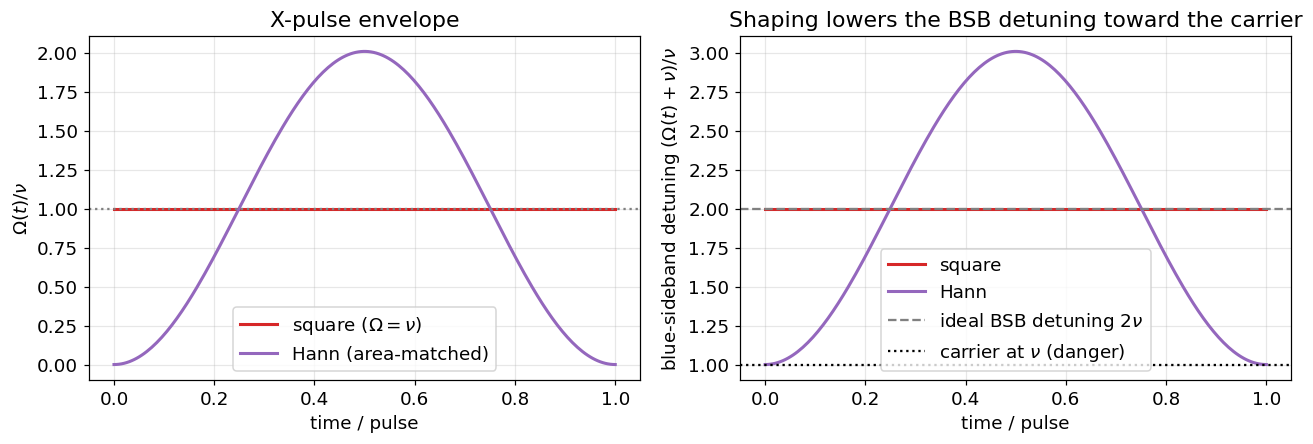

In [11]:
# Visualise the mechanism: the envelope drags the blue-sideband detuning down from 2nu
M = 200; t = np.linspace(0, 1, M)
env_sq = window("square", M); env_cs = window("cos", M)
# normalise both to the same area (peak of cos is ~2x the square here)
env_sq_n = env_sq*1.0
env_cs_n = env_cs*(np.sum(env_sq)/np.sum(env_cs))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
a1.plot(t, env_sq_n, color='tab:red',   lw=2, label='square ($\\Omega=\\nu$)')
a1.plot(t, env_cs_n, color='tab:purple',lw=2, label='Hann (area-matched)')
a1.axhline(1.0, color='gray', ls=':')
a1.set_xlabel('time / pulse'); a1.set_ylabel(r'$\Omega(t)/\nu$'); a1.set_title('X-pulse envelope')
a1.legend(); a1.grid(True, alpha=0.3)

a2.plot(t, env_sq_n + 1.0, color='tab:red',   lw=2, label='square')
a2.plot(t, env_cs_n + 1.0, color='tab:purple',lw=2, label='Hann')
a2.axhline(2.0, color='gray', ls='--', label=r'ideal BSB detuning $2\nu$')
a2.axhline(1.0, color='k', ls=':', label=r'carrier at $\nu$ (danger)')
a2.set_xlabel('time / pulse'); a2.set_ylabel(r'blue-sideband detuning $(\Omega(t)+\nu)/\nu$')
a2.set_title('Shaping lowers the BSB detuning toward the carrier'); a2.legend(); a2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Mechanism, confirmed.** The pure-JC model is **completely insensitive** to amplitude
shaping (trace distance stays at machine zero for every window) — because there the only
thing that matters is the pulse *area*, which we hold fixed. The full Rabi model, by
contrast, degrades under shaping. The difference between the two models is precisely the
$\tfrac{\Omega}{2}\sigma_z$ term and the counter-rotating coupling. The right panel shows
the consequence: a square pulse holds the blue-sideband detuning at $2\nu$ for the whole
pulse, whereas any smooth envelope sweeps it down toward the carrier at $\nu$, where the
unwanted term is *more* resonant. Amplitude shaping therefore trades a small reduction of
spectral weight at $2\nu$ for a large increase in near-resonant leakage — a losing trade.

**The deeper point:** amplitude shaping is the standard tool when the drive amplitude is an
independent knob (as in the *weak-driving* SPT protocol, where $\Omega\ll\nu$ is fixed and a
smooth pulse suppresses carrier excitation). In the *resonant* protocol the amplitude is
**locked** to $\Omega=\nu$ by construction, so it is no longer a free shaping handle.

## 3. Conclusion — the right "shaping" lives in (length, detuning)

Because $\Omega$ must stay pinned at $\nu$, the continuous handles that remain are the
**pulse length** and the **detuning** — exactly the two knobs of approach (2). In that
sense, refocusing + Bloch–Siegert detuning *is* the correct pulse-shaping for this protocol:
it shapes the pulse in the $(f,\delta)$ space while keeping the amplitude where the physics
needs it. The benchmark in Section 1 makes the ranking explicit:

- **(1) nominal square** — fast but leaks at large $\eta$;
- **(3) amplitude-shaped** — *worse* than nominal, for the reason above;
- **(2) refocusing + detuning** — an order of magnitude better, and the recommended route.

**Outlook.** The genuinely useful shaped degree of freedom that respects $\Omega=\nu$ is a
**time-dependent detuning** $\delta(t)$ rather than an amplitude envelope. We implement and
test it in **Section 4** below: it generalises the constant Bloch–Siegert detuning of
approach (2), and — unlike amplitude shaping — it cannot drag the blue sideband toward
resonance, so it genuinely helps.

## 4. The right shaped knob: a time-dependent detuning $\delta(t)$

The lesson of Sections 2–3 is that the *amplitude* must stay pinned at $\Omega=\nu$, so the
only continuous handle left to "shape" is the **detuning**. Unlike an amplitude envelope, a
time-dependent detuning $\delta(t)$ keeps the drive at $\Omega=\nu$ and therefore never drags
the blue sideband toward resonance — it simply adds a controllable, time-resolved
$\tfrac{\delta(t)}{2}\sigma_z$ term to the X-pulse.

We test a few detuning profiles (all with $\Omega=\nu$ fixed), optimising only their
amplitude per $\eta$:

- **constant** $\delta$ — the Bloch–Siegert compensation of the companion notebook;
- **bump** — a smooth pulse centred in the middle of the X-pulse;
- **edges** — detuning concentrated at the turn-on/turn-off, where the counter-rotating
  phase has not yet refocused;
- **ramp** — an antisymmetric chirp.

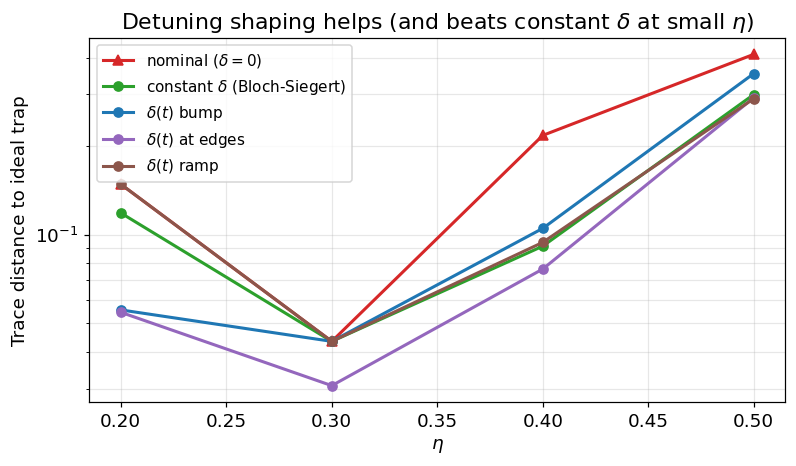

  eta   nominal     const      bump     edges      ramp
  0.2    0.1485    0.1186    0.0556    0.0545    0.1485
  0.3    0.0434    0.0434    0.0434    0.0307    0.0434
  0.4    0.2176    0.0915    0.1051    0.0765    0.0942
  0.5    0.4102    0.2996    0.3529    0.2921    0.2901


In [12]:
def detuning_profile(name, M, amp):
    t = np.linspace(0, 1, M)
    if name == "const": return amp*np.ones(M)
    if name == "bump":  return amp*np.exp(-((t-0.5)/0.2)**2)
    if name == "edges": return amp*(np.exp(-(t/0.2)**2) + np.exp(-((t-1)/0.2)**2))
    if name == "ramp":  return amp*(2*t - 1)
    raise ValueError(name)

def prep_chirp(eta, profile="const", amp=0.0, f=1.0, M=40, Omega_y=100.0, RF=1.0):
    D = Dop(eta); tau = f*2*np.pi/(eta*Omega*np.sqrt(n0)); dt = tau/M
    dprof = detuning_profile(profile, M, amp)
    U_x = tensor(qeye(2), qeye(N))
    for k in range(M):                            # Omega fixed at nu; only the detuning varies
        Hk = 0.5*dprof[k]*sx + nu*num + 0.5*Omega*(sp*D + sm*D.dag())
        U_x = (-1j*Hk*dt).expm()*U_x
    U_rf = (-1j*0.5*RF*(A+Ad)*(eta/RF)).expm(); U_rf_u = U_rf.dag()
    H_y = 0.5*Omega_y*(-1j*sp*D + 1j*sm*D.dag()); ty = np.pi/(2*Omega_y)
    U_y = (-1j*H_y*ty).expm(); U_y_u = (1j*H_y*ty).expm()
    return _iterate(U_rf_u*U_y_u*U_x*U_y*U_rf, eta)

amps = np.linspace(-0.4, 0.4, 17)
profiles = ["const", "bump", "edges", "ramp"]
etas3 = [0.2, 0.3, 0.4, 0.5]

td_chirp = {pr: [] for pr in profiles}
td_chirp_nom = []
for e in etas3:
    td_chirp_nom.append(tdist(prep_chirp(e), pid))   # amp=0 -> nominal square
    for pr in profiles:
        td_chirp[pr].append(min(tdist(prep_chirp(e, pr, A_), pid) for A_ in amps))

prof_col = {"const":"tab:green", "bump":"tab:blue", "edges":"tab:purple", "ramp":"tab:brown"}
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(etas3, td_chirp_nom, '^-', color='tab:red', lw=2, label='nominal ($\\delta=0$)')
for pr in profiles:
    lbl = {'const':'constant $\\delta$ (Bloch-Siegert)', 'bump':'$\\delta(t)$ bump',
           'edges':'$\\delta(t)$ at edges', 'ramp':'$\\delta(t)$ ramp'}[pr]
    ax.plot(etas3, td_chirp[pr], 'o-', color=prof_col[pr], lw=2, label=lbl)
ax.set_xlabel(r'$\eta$'); ax.set_ylabel('Trace distance to ideal trap')
ax.set_yscale('log'); ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=10)
ax.set_title('Detuning shaping helps (and beats constant $\\delta$ at small $\\eta$)')
plt.tight_layout(); plt.show()

print(f"{'eta':>5} {'nominal':>9} {'const':>9} {'bump':>9} {'edges':>9} {'ramp':>9}")
for i, e in enumerate(etas3):
    print(f"{e:>5} {td_chirp_nom[i]:>9.4f} " + " ".join(f"{td_chirp[pr][i]:>9.4f}" for pr in profiles))

**Result — and the contrast with amplitude shaping.** No detuning profile degrades
the nominal protocol, which is already the opposite of the amplitude-envelope
behaviour in Section 1. More interestingly, a **shaped** $\delta(t)$ — especially the one
concentrated at the pulse edges — **beats a constant detuning** at small-to-moderate $\eta$
(e.g. roughly $2\times$ lower trace distance at $\eta=0.2$), because it targets the turn-on/
turn-off where the counter-rotating excursion has not yet refocused. This is the natural
generalisation of the constant Bloch–Siegert detuning and points to detuning shaping (rather
than amplitude shaping) as the productive direction.

For the lowest residuals one still combines this detuning handle with the **pulse-length
refocusing** of the companion notebook (here we left $f=1$ to isolate the detuning effect);
together they form the genuine "pulse-shaping" space for the resonant protocol — the
amplitude is simply not part of it.

**Bottom line.**

| knob | status | why |
|---|---|---|
| amplitude envelope $\Omega(t)$ | ❌ counterproductive | drags the blue sideband from $2\nu$ toward $\nu$ |
| detuning $\delta$ (constant) | ✅ works | cancels the Bloch–Siegert shift at fixed $\Omega=\nu$ |
| detuning $\delta(t)$ (shaped) | ✅ works, often better | refocuses the residual shift, esp. at the pulse edges |
| pulse length $f$ | ✅ works | blue-sideband (commensurability) refocusing |

## Publication figures

The cell below regenerates the publication-quality PDF figures used in the manuscript (saved into `figures/`). The computations live in `make_paper_figures.py`, which reproduces the analysis of this notebook; results are checkpointed in `figgen_cache.pkl`, so re-running is fast.

In [13]:
from make_paper_figures import figure_pulse_shaping
figure_pulse_shaping()

[fig 7] amplitude windows ...
[fig 7] detuning profiles ...
[fig 7] saved -> figures/figure_7.pdf
